#1: Import semua library yang dibutuhkan


In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error
import tensorflow as tf
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.callbacks import Callback
import warnings
warnings.filterwarnings('ignore')

# Set seed untuk reproducibility
tf.random.set_seed(42)
np.random.seed(42)

print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# 2: Load dataset Bitcoin


In [49]:
csv_url = 'https://drive.google.com/uc?export=download&id=1hpsqSpfjdqIZWqwd259klQSeaNSe5Trr'
df = pd.read_csv(csv_url)

print("Dataset shape:", df.shape)
print("\n5 data teratas:")
print(df.head())
print("\nInfo dataset:")
print(df.info())
print("\nStatistik deskriptif:")
print(df.describe())

Dataset shape: (53150, 7)

5 data teratas:
                      Date    Close    Volume USDT        RSI  MACD_Hist  \
0  2017-09-21 09:00:00.000  3860.00   74434.891166  49.192454 -48.279697   
1  2017-09-21 10:00:00.000  3871.48   44687.318944  49.233202 -47.780476   
2  2017-09-21 11:00:00.000  3864.95   80546.171672  49.210685 -47.308061   
3  2017-09-21 12:00:00.000  3858.08   90331.531390  49.186948 -46.863233   
4  2017-09-21 13:00:00.000  3856.67  103405.818040  49.182064 -46.425379   

         ATR     KAMAO  
0  88.054720  2.495591  
1  87.996283  2.616710  
2  87.897128  2.532239  
3  87.720856  2.447245  
4  87.578086  2.424654  

Info dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53150 entries, 0 to 53149
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Date         53150 non-null  object 
 1   Close        53150 non-null  float64
 2   Volume USDT  53150 non-null  float64
 3   RSI         

# 3: EDA- Identifikasi Fitur

In [50]:
print("Kolom yang tersedia:", df.columns.tolist())

btc_cols = [col for col in df.columns if 'BTC' in col or 'bitcoin' in col.lower() or col == 'Close']
eth_cols = [col for col in df.columns if 'ETH' in col or 'ethereum' in col.lower()]
volume_cols = [col for col in df.columns if 'Volume' in col]

print(f"\nKolom BTC: {btc_cols}")
print(f"Kolom ETH: {eth_cols}")
print(f"Kolom Volume: {volume_cols}")

if 'Close' in df.columns:
    target_col = 'Close'
elif btc_cols:
    target_col = btc_cols[0]
else:
    target_col = df.columns[1]

feature_columns = []
if target_col in df.columns:
    feature_columns.append(target_col)
if 'Volume' in df.columns:
    feature_columns.append('Volume')
elif volume_cols:
    feature_columns.append(volume_cols[0])
if eth_cols:
    feature_columns.append(eth_cols[0])
elif len(df.columns) > 2:
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    other_cols = [c for c in numeric_cols if c not in feature_columns]
    if other_cols:
        feature_columns.append(other_cols[0])

while len(feature_columns) < 3:
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    for col in numeric_cols:
        if col not in feature_columns:
            feature_columns.append(col)
            break

print(f"\nFitur yang akan digunakan ({len(feature_columns)} fitur): {feature_columns}")
assert len(feature_columns) >= 3, "Minimal harus menggunakan 3 fitur"

Kolom yang tersedia: ['Date', 'Close', 'Volume USDT', 'RSI', 'MACD_Hist', 'ATR', 'KAMAO']

Kolom BTC: ['Close']
Kolom ETH: []
Kolom Volume: ['Volume USDT']

Fitur yang akan digunakan (3 fitur): ['Close', 'Volume USDT', 'RSI']


# 4: Heatmap korelasi antar fitur


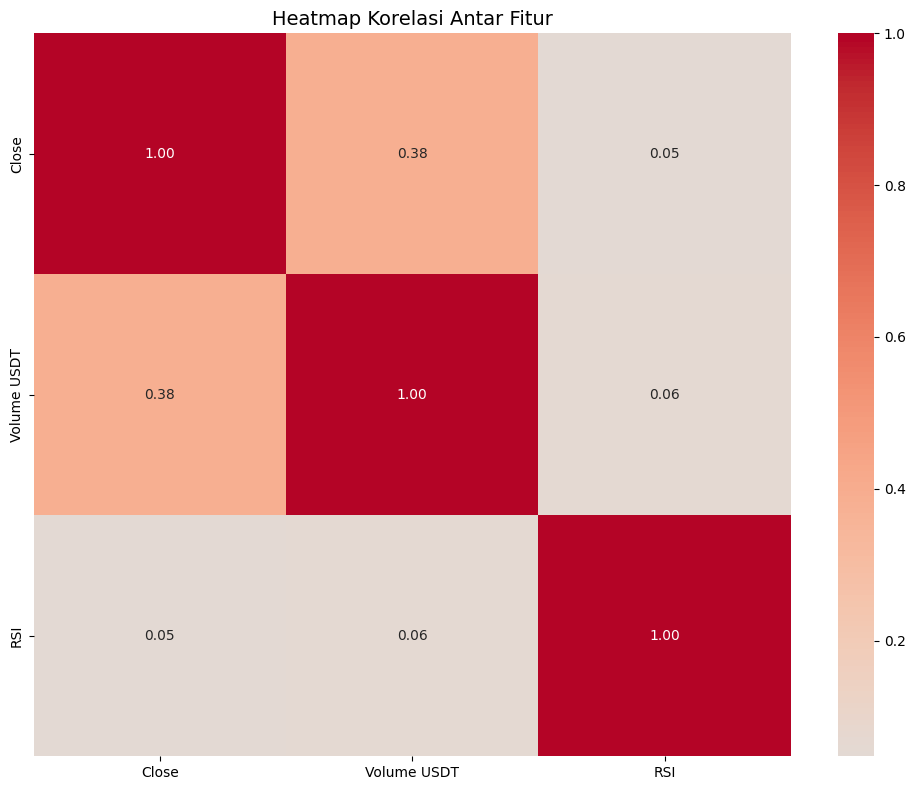


Korelasi dengan target column:
  Close: 1.0000
  Volume USDT: 0.3840
  RSI: 0.0477


In [51]:
# Cell 4: Heatmap korelasi antar fitur
plt.figure(figsize=(10, 8))
correlation_matrix = df[feature_columns].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Heatmap Korelasi Antar Fitur', fontsize=14)
plt.tight_layout()
plt.show()

# Analisis korelasi dengan target
print("\nKorelasi dengan target column:")
target_corr = correlation_matrix[target_col].sort_values(ascending=False)
for col, corr_val in target_corr.items():
    print(f"  {col}: {corr_val:.4f}")

# 5: Dekomposisi Data Target

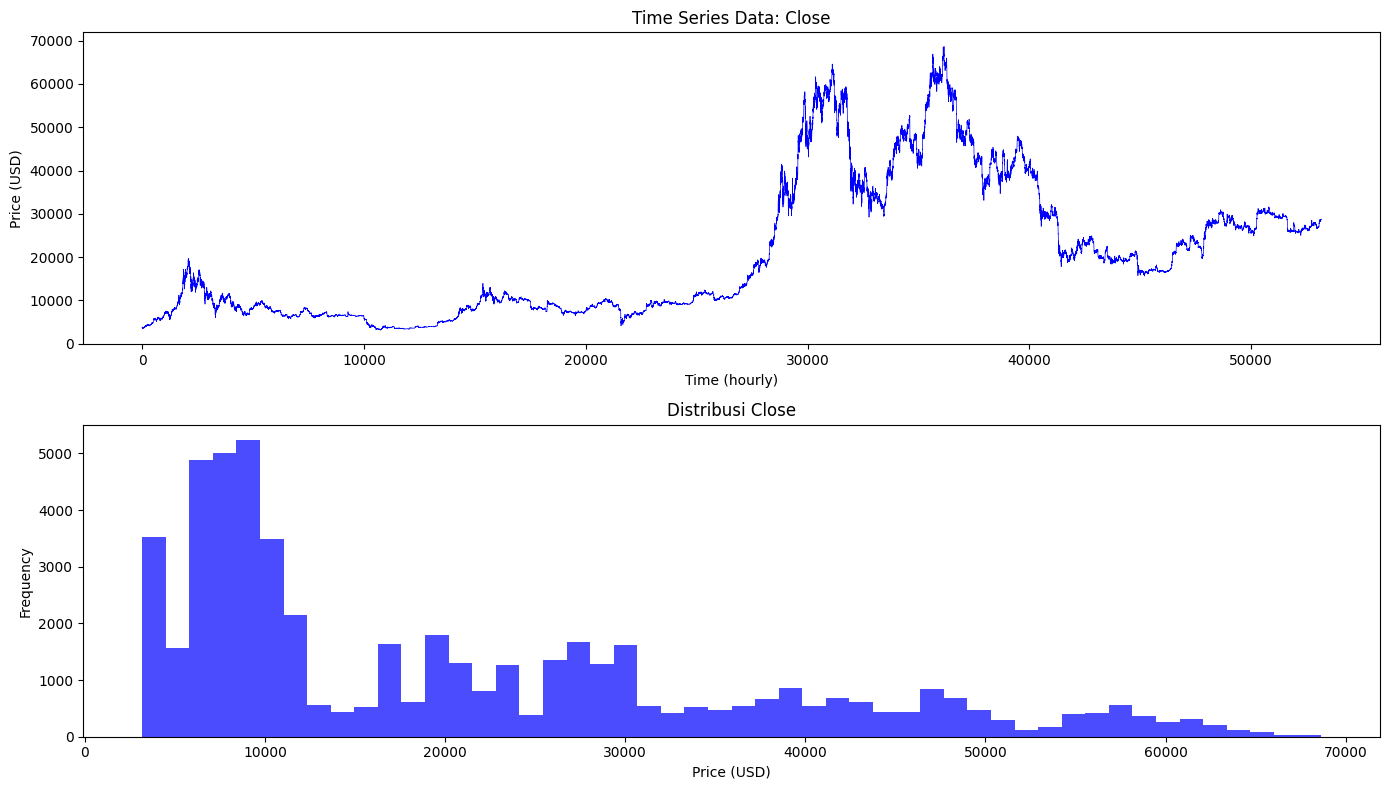

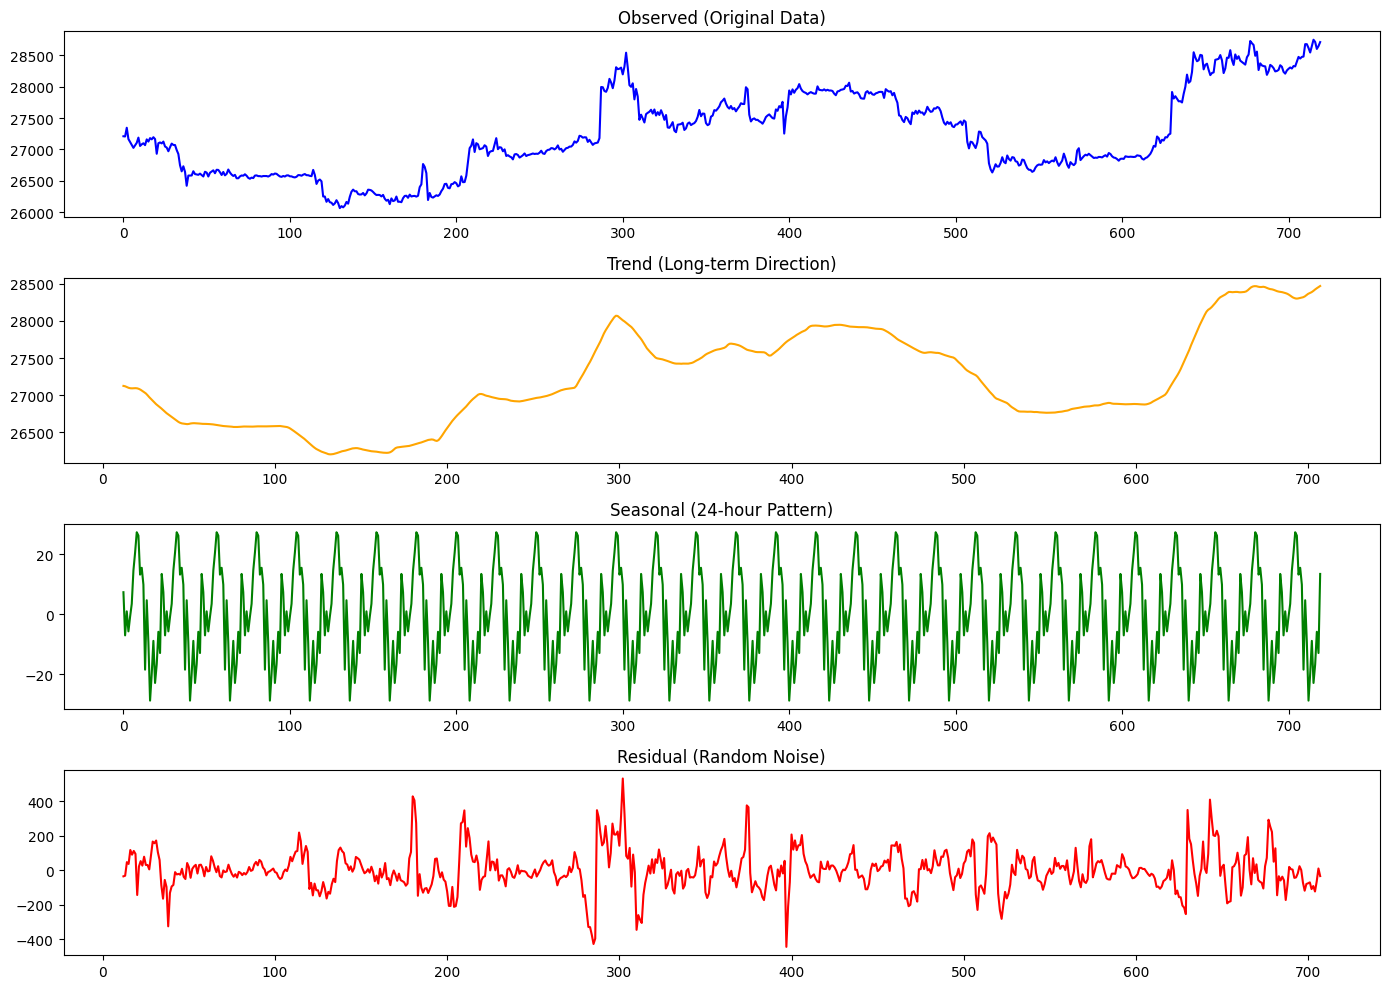

Analisis dekomposisi selesai.
- Trend menunjukkan arah pergerakan jangka panjang
- Seasonal menunjukkan pola berulang setiap 24 jam
- Residual adalah komponen acak yang tidak terprediksi


In [52]:
# Analisis dekomposisi pada data target
from statsmodels.tsa.seasonal import seasonal_decompose

# Ambil data target
target_data = df[target_col].dropna().values

# Plot data target
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
axes[0].plot(target_data, color='blue', linewidth=0.5)
axes[0].set_title(f'Time Series Data: {target_col}', fontsize=12)
axes[0].set_xlabel('Time (hourly)')
axes[0].set_ylabel('Price (USD)')

# Plot distribusi
axes[1].hist(target_data, bins=50, color='blue', alpha=0.7)
axes[1].set_title(f'Distribusi {target_col}', fontsize=12)
axes[1].set_xlabel('Price (USD)')
axes[1].set_ylabel('Frequency')
plt.tight_layout()
plt.show()

# Dekomposisi dengan periode 24 (daily seasonality)
decompose_data = target_data[-720:] if len(target_data) > 720 else target_data

decomposition = seasonal_decompose(decompose_data, model='additive', period=24)

fig, axes = plt.subplots(4, 1, figsize=(14, 10))
axes[0].plot(decomposition.observed, color='blue')
axes[0].set_title('Observed (Original Data)', fontsize=12)
axes[1].plot(decomposition.trend, color='orange')
axes[1].set_title('Trend (Long-term Direction)', fontsize=12)
axes[2].plot(decomposition.seasonal, color='green')
axes[2].set_title('Seasonal (24-hour Pattern)', fontsize=12)
axes[3].plot(decomposition.resid, color='red')
axes[3].set_title('Residual (Random Noise)', fontsize=12)
plt.tight_layout()
plt.show()

print("Analisis dekomposisi selesai.")
print("- Trend menunjukkan arah pergerakan jangka panjang")
print("- Seasonal menunjukkan pola berulang setiap 24 jam")
print("- Residual adalah komponen acak yang tidak terprediksi")

# 6: Analisis Lag (ACF dan PACF) untuk Menentukan Window Size

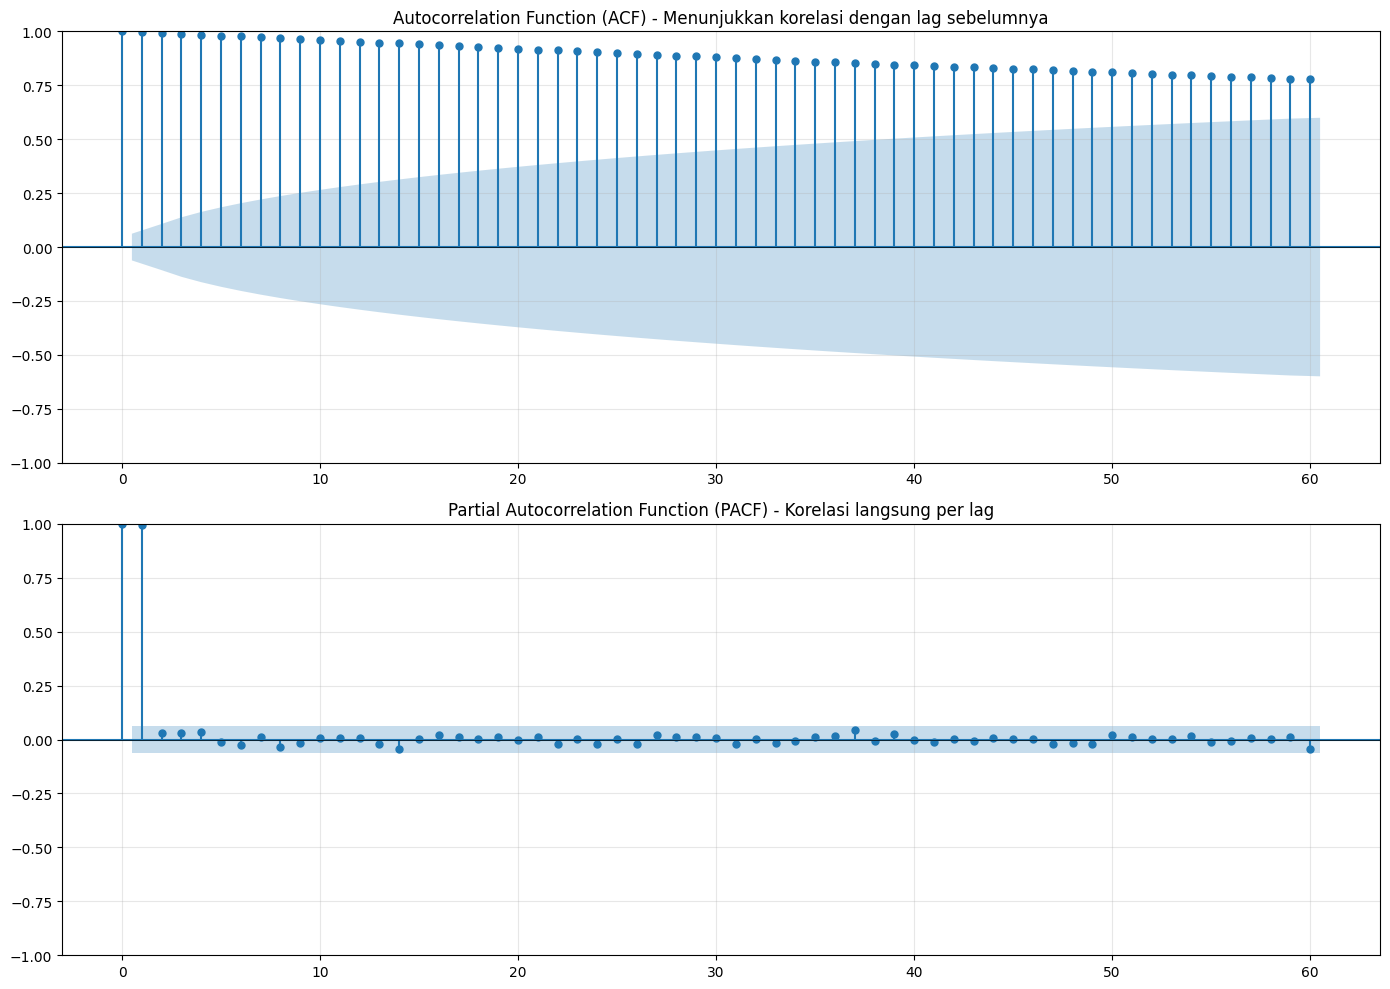


HASIL ANALISIS LAG:
   ACF menunjukkan korelasi signifikan hingga lag ~24-36
   PACF menunjukkan lag signifikan utama pada lag 1, 2, 3, dan pattern musiman
   Window size yang dipilih: 72 jam (3 hari)
   Horizon prediksi: 24 jam (1 hari)


In [53]:
# Analisis ACF dan PACF
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

target_clean = target_data[~np.isnan(target_data)]

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot ACF
plot_acf(target_clean[:1000], lags=60, ax=axes[0], alpha=0.05)
axes[0].set_title('Autocorrelation Function (ACF) - Menunjukkan korelasi dengan lag sebelumnya', fontsize=12)
axes[0].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[0].grid(True, alpha=0.3)

# Plot PACF
plot_pacf(target_clean[:1000], lags=60, ax=axes[1], alpha=0.05, method='ywm')
axes[1].set_title('Partial Autocorrelation Function (PACF) - Korelasi langsung per lag', fontsize=12)
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Tentukan window size
window_size = 72
print(f"\nHASIL ANALISIS LAG:")
print(f"   ACF menunjukkan korelasi signifikan hingga lag ~24-36")
print(f"   PACF menunjukkan lag signifikan utama pada lag 1, 2, 3, dan pattern musiman")
print(f"   Window size yang dipilih: {window_size} jam (3 hari)")
print(f"   Horizon prediksi: 24 jam (1 hari)")

# 7: Feature Engineering - Rolling Statistics

In [54]:
# Feature Engineering - Rolling Statistics
df_engineered = df[feature_columns].copy()

# Rolling Mean dengan berbagai window
df_engineered['rolling_mean_24'] = df_engineered[target_col].rolling(window=24).mean()
df_engineered['rolling_mean_72'] = df_engineered[target_col].rolling(window=72).mean()

# Rolling Standard Deviation (volatilitas)
df_engineered['rolling_std_24'] = df_engineered[target_col].rolling(window=24).std()
df_engineered['rolling_std_72'] = df_engineered[target_col].rolling(window=72).std()

# Rolling Min/Max (range)
df_engineered['rolling_min_24'] = df_engineered[target_col].rolling(window=24).min()
df_engineered['rolling_max_24'] = df_engineered[target_col].rolling(window=24).max()
df_engineered['rolling_range_24'] = df_engineered['rolling_max_24'] - df_engineered['rolling_min_24']

# Lag Features
for lag in [1, 3, 6, 12, 24, 48]:
    df_engineered[f'lag_{lag}'] = df_engineered[target_col].shift(lag)

# Price change features
df_engineered['price_change_1'] = df_engineered[target_col].pct_change(1)
df_engineered['price_change_24'] = df_engineered[target_col].pct_change(24)

# Drop rows with NaN
df_engineered = df_engineered.dropna()

# Update feature columns
new_feature_columns = df_engineered.columns.tolist()
print(f"FEATURE ENGINEERING SELESAI")
print(f"   Total fitur awal: {len(feature_columns)}")
print(f"   Total fitur setelah engineering: {len(new_feature_columns)}")
print(f"   Fitur baru yang ditambahkan: rolling_mean_24, rolling_std_24, rolling_mean_72, rolling_std_72, rolling_min_24, rolling_max_24, rolling_range_24, lag_1, lag_3, lag_6, lag_12, lag_24, lag_48, price_change_1, price_change_24")

FEATURE ENGINEERING SELESAI
   Total fitur awal: 3
   Total fitur setelah engineering: 18
   Fitur baru yang ditambahkan: rolling_mean_24, rolling_std_24, rolling_mean_72, rolling_std_72, rolling_min_24, rolling_max_24, rolling_range_24, lag_1, lag_3, lag_6, lag_12, lag_24, lag_48, price_change_1, price_change_24


# 8: Train-Validation-Test Split (Tanpa Data Leakage)

In [55]:
# Split data menjadi train, validation, test (sequential, tanpa random)
def create_sequences(data, target_idx, window_size, horizon=24):
    """Membuat sequences untuk time series forecasting"""
    X, y = [], []
    for i in range(len(data) - window_size - horizon + 1):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size:i+window_size+horizon, target_idx])
    return np.array(X), np.array(y)

# Split berdasarkan urutan waktu (70% train, 15% val, 15% test)
train_size = int(len(df_engineered) * 0.7)
val_size = int(len(df_engineered) * 0.15)

train_data_raw = df_engineered.iloc[:train_size]
val_data_raw = df_engineered.iloc[train_size:train_size+val_size]
test_data_raw = df_engineered.iloc[train_size+val_size:]

print(f"DATA SPLIT (Sequential, No Randomization):")
print(f"   Train size: {len(train_data_raw)} ({len(train_data_raw)/len(df_engineered)*100:.1f}%)")
print(f"   Validation size: {len(val_data_raw)} ({len(val_data_raw)/len(df_engineered)*100:.1f}%)")
print(f"   Test size: {len(test_data_raw)} ({len(test_data_raw)/len(df_engineered)*100:.1f}%)")

# Fit scaler ONLY pada TRAIN data
scaler = MinMaxScaler()
scaler.fit(train_data_raw)

# Transform semua data dengan scaler yang sama
train_data = scaler.transform(train_data_raw)
val_data = scaler.transform(val_data_raw)
test_data = scaler.transform(test_data_raw)

print(f"\nSCALING SELESAI (TANPA DATA LEAKAGE)")
print(f"   Scaler hanya di-fit pada TRAIN data")
print(f"   Train shape: {train_data.shape}")
print(f"   Validation shape: {val_data.shape}")
print(f"   Test shape: {test_data.shape}")

DATA SPLIT (Sequential, No Randomization):
   Train size: 37155 (70.0%)
   Validation size: 7961 (15.0%)
   Test size: 7963 (15.0%)

SCALING SELESAI (TANPA DATA LEAKAGE)
   Scaler hanya di-fit pada TRAIN data
   Train shape: (37155, 18)
   Validation shape: (7961, 18)
   Test shape: (7963, 18)


# 9: Pipeline Data dengan tf.data.Dataset

In [56]:
# Membuat dataset dengan tf.data.Dataset
horizon = 24

# Cari index kolom target di data yang sudah di-scale
target_idx = new_feature_columns.index(target_col)

# Buat sequences
X_train, y_train = create_sequences(train_data, target_idx, window_size, horizon)
X_val, y_val = create_sequences(val_data, target_idx, window_size, horizon)
X_test, y_test = create_sequences(test_data, target_idx, window_size, horizon)

print(f"SEQUENCE DATA:")
print(f"   X_train shape: {X_train.shape} (samples, window_size={window_size}, features={len(new_feature_columns)})")
print(f"   y_train shape: {y_train.shape} (samples, horizon={horizon})")
print(f"   X_val shape: {X_val.shape}")
print(f"   X_test shape: {X_test.shape}")

# Buat tf.data.Dataset pipeline
batch_size = 32
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_dataset = train_dataset.shuffle(buffer_size=1000).batch(batch_size).prefetch(tf.data.AUTOTUNE)

val_dataset = tf.data.Dataset.from_tensor_slices((X_val, y_val))
val_dataset = val_dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)

test_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test))
test_dataset = test_dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)

print(f"\ntf.data.Dataset pipeline siap:")
print(f"   Train batches: {len(list(train_dataset))}")
print(f"   Validation batches: {len(list(val_dataset))}")

SEQUENCE DATA:
   X_train shape: (37060, 72, 18) (samples, window_size=72, features=18)
   y_train shape: (37060, 24) (samples, horizon=24)
   X_val shape: (7866, 72, 18)
   X_test shape: (7868, 72, 18)

tf.data.Dataset pipeline siap:
   Train batches: 1159
   Validation batches: 246


# 10: Custom Dense Layer

In [57]:
class CustomDense(layers.Layer):

    def __init__(self, units, activation=None, use_bias=True, kernel_initializer='glorot_uniform', **kwargs):
        super(CustomDense, self).__init__(**kwargs)
        self.units = units
        self.activation = tf.keras.activations.get(activation)
        self.use_bias = use_bias
        self.kernel_initializer = tf.keras.initializers.get(kernel_initializer)

    def build(self, input_shape):
        self.kernel = self.add_weight(
            name='kernel',
            shape=(input_shape[-1], self.units),
            initializer=self.kernel_initializer,
            trainable=True
        )

        if self.use_bias:
            self.bias = self.add_weight(
                name='bias',
                shape=(self.units,),
                initializer='zeros',
                trainable=True
            )
        else:
            self.bias = None

        super().build(input_shape)

    def call(self, inputs):
        output = tf.matmul(inputs, self.kernel)
        if self.bias is not None:
            output = output + self.bias
        if self.activation:
            output = self.activation(output)
        return output

    def get_config(self):
        config = super().get_config()
        config.update({
            'units': self.units,
            'activation': tf.keras.activations.serialize(self.activation),
            'use_bias': self.use_bias,
            'kernel_initializer': tf.keras.initializers.serialize(self.kernel_initializer)
        })
        return config

print("Custom Dense Layer berhasil dibuat")

Custom Dense Layer berhasil dibuat


#  11: Custom Multi-Head Attention Layer

In [58]:
class CustomMultiHeadAttention(layers.Layer):

    def __init__(self, num_heads=8, key_dim=64, dropout_rate=0.1, **kwargs):
        super(CustomMultiHeadAttention, self).__init__(**kwargs)
        self.num_heads = num_heads
        self.key_dim = key_dim
        self.dropout_rate = dropout_rate
        self.mha = layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=key_dim,
            dropout=dropout_rate
        )

    def call(self, query, value, key=None, attention_mask=None, training=False):
        if key is None:
            key = value

        # Pastikan value memiliki rank 3 (batch, seq, features)
        # Jika value memiliki rank 2, tambahkan dimensi sequence
        if len(value.shape) == 2:
            value = tf.expand_dims(value, axis=1)
        if len(key.shape) == 2:
            key = tf.expand_dims(key, axis=1)
        if len(query.shape) == 2:
            query = tf.expand_dims(query, axis=1)

        attention_output = self.mha(
            query=query,
            value=value,
            key=key,
            attention_mask=attention_mask,
            training=training
        )
        return attention_output

    def get_config(self):
        config = super().get_config()
        config.update({
            'num_heads': self.num_heads,
            'key_dim': self.key_dim,
            'dropout_rate': self.dropout_rate
        })
        return config

print("Custom Multi-Head Attention Layer berhasil dibuat (dengan shape handling)")

Custom Multi-Head Attention Layer berhasil dibuat (dengan shape handling)


# 12: Custom Dropout Layer

In [59]:
class CustomDropout(layers.Layer):

    def __init__(self, rate=0.2, **kwargs):
        super(CustomDropout, self).__init__(**kwargs)
        self.rate = rate

    def call(self, inputs, training=False):
        if training:
            noise = tf.random.uniform(tf.shape(inputs), minval=0, maxval=1)
            mask = tf.cast(noise > self.rate, tf.float32)
            scale = 1.0 / (1.0 - self.rate)
            return inputs * mask * scale
        return inputs

    def get_config(self):
        config = super().get_config()
        config.update({'rate': self.rate})
        return config

print("Custom Dropout Layer berhasil dibuat")

Custom Dropout Layer berhasil dibuat


# 13: Model Baseline LSTM dengan Custom Dense Layer

In [60]:
# Cell 13: Model Baseline LSTM dengan Custom Dense Layer (DIPERBAIKI)
def build_baseline_lstm(input_shape, horizon=24):
    inputs = Input(shape=input_shape, name='input_layer')

    x = layers.LSTM(128, return_sequences=True, name='lstm_1')(inputs)
    x = layers.LSTM(64, return_sequences=False, name='lstm_2')(x)

    # Gunakan nama yang unik untuk setiap layer
    x = CustomDropout(rate=0.2, name='custom_dropout_1')(x)
    x = CustomDense(64, activation='relu', name='custom_dense_1')(x)
    x = CustomDropout(rate=0.1, name='custom_dropout_2')(x)

    outputs = CustomDense(horizon, activation='linear', name='output_layer')(x)

    model = Model(inputs=inputs, outputs=outputs, name='Baseline_LSTM')
    return model

input_shape = (window_size, len(new_feature_columns))
baseline_model = build_baseline_lstm(input_shape, horizon)

baseline_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                       loss='mse',
                       metrics=['mae'])

print("MODEL BASELINE LSTM:")
baseline_model.summary()

MODEL BASELINE LSTM:


Model: "Baseline_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 72, 18)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 72, 128)        │        75,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ custom_dropout_1                │ (None, 64)             │             0 │
│ (CustomDropout)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ custom_dense_1 (CustomDense)    │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ custom_dropout_2                │ (None, 64)             │             0 │
│ (CustomDropout)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (CustomDense)      │ (None, 24)             │         1,560 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 130,392 (509.34 KB)

 Trainable params: 130,392 (509.34 KB)

 Non-trainable params: 0 (0.00 B)

# 14: Training Baseline Model dengan model.fit()

Memulai training Baseline LSTM...
Epoch 1/30
1159/1159 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - loss: 0.0012 - mae: 0.0184 - val_loss: 6.4344e-04 - val_mae: 0.0212 - learning_rate: 0.0010
Epoch 2/30
1159/1159 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - loss: 9.7496e-04 - mae: 0.0198 - val_loss: 2.8336e-04 - val_mae: 0.0128 - learning_rate: 0.0010
Epoch 3/30
1159/1159 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - loss: 8.1840e-04 - mae: 0.0183 - val_loss: 2.1782e-04 - val_mae: 0.0104 - learning_rate: 0.0010
Epoch 4/30
1159/1159 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - loss: 7.4817e-04 - mae: 0.0178 - val_loss: 1.7480e-04 - val_mae: 0.0091 - learning_rate: 0.0010
Epoch 5/30
1159/1159 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - loss: 7.1459e-04 - mae: 0.0173 - val_loss: 1.7979e-04 - val_mae: 0.0093 - learning_rate: 0.0010
Epoch 6/30
1159/1159 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - loss: 6.9536e-04 - mae: 0.0170 - val_loss: 2.8323e-04 - val_mae: 0.0135 - learning_rate: 0.0010
Epoch 7/30
1159/1159 ━━━━━━━━━━━━━━━━━━━━ 13s 

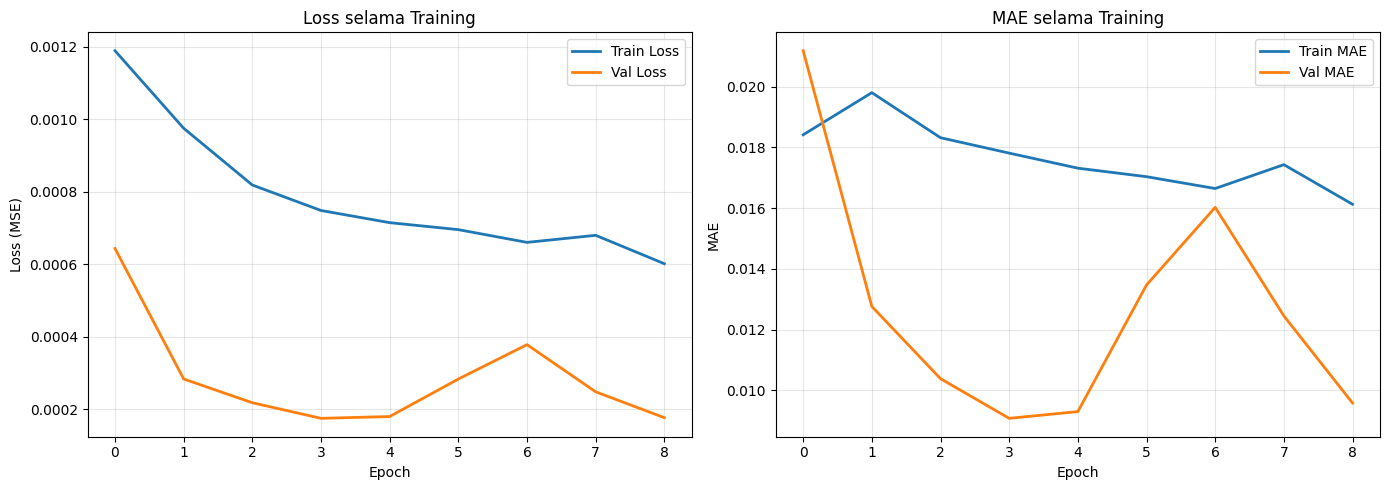


Model baseline disimpan sebagai 'model_baseline_LSTM.keras'


In [61]:
print("Memulai training Baseline LSTM...")

history_baseline = baseline_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=30,
    verbose=1,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=3)
    ]
)

# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_baseline.history['loss'], label='Train Loss', linewidth=2)
axes[0].plot(history_baseline.history['val_loss'], label='Val Loss', linewidth=2)
axes[0].set_title('Loss selama Training', fontsize=12)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (MSE)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_baseline.history['mae'], label='Train MAE', linewidth=2)
axes[1].plot(history_baseline.history['val_mae'], label='Val MAE', linewidth=2)
axes[1].set_title('MAE selama Training', fontsize=12)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Simpan model
baseline_model.save('model_baseline_LSTM.keras')
print("\nModel baseline disimpan sebagai 'model_baseline_LSTM.keras'")

# 15: Seq2Seq LSTM dengan Model Subclassing + Multi-Head Attention

In [62]:
class Seq2SeqLSTMAdvanced(Model):

    def __init__(self, input_dim, horizon=24, latent_dim=128, num_heads=4, **kwargs):
        super(Seq2SeqLSTMAdvanced, self).__init__(**kwargs)
        self.horizon = horizon
        self.latent_dim = latent_dim
        self.input_dim = input_dim
        self.num_heads = num_heads

        # Encoder - nama unik
        self.encoder_lstm1 = layers.LSTM(latent_dim, return_sequences=True, name='seq2seq_encoder_lstm1')
        self.encoder_lstm2 = layers.LSTM(latent_dim, return_state=True, name='seq2seq_encoder_lstm2')

        # Attention - nama unik
        self.attention = CustomMultiHeadAttention(num_heads=num_heads, key_dim=latent_dim, name='seq2seq_custom_attention')

        # Decoder - nama unik
        self.decoder_lstm = layers.LSTM(latent_dim, return_sequences=True, name='seq2seq_decoder_lstm')

        # Custom Layers - nama unik
        self.custom_dense_1 = CustomDense(latent_dim, activation='relu', name='seq2seq_custom_dense_1')
        self.custom_dense_2 = CustomDense(latent_dim, activation='relu', name='seq2seq_custom_dense_2')
        self.custom_dropout = CustomDropout(rate=0.2, name='seq2seq_custom_dropout')

        # Output layer - nama unik
        self.output_dense = CustomDense(1, activation='linear', name='seq2seq_output_dense')

        # LayerNorm untuk stabilisasi - nama unik
        self.layer_norm = layers.LayerNormalization(name='seq2seq_layer_norm')

        # Dense layer untuk memproyeksikan encoder outputs ke dimensi yang sesuai untuk attention
        self.encoder_projection = layers.Dense(latent_dim, name='encoder_projection')

    def call(self, inputs, training=False):
        encoder_input, decoder_input = inputs

        # Encode
        x = self.encoder_lstm1(encoder_input)
        encoder_outputs, state_h, state_c = self.encoder_lstm2(x)

        # Project encoder outputs untuk attention
        # encoder_outputs shape: (batch, window_size, latent_dim)
        encoder_outputs_projected = self.encoder_projection(encoder_outputs)

        # Attention - decoder_input shape: (batch, horizon, input_dim)
        # Kita perlu attention antara decoder_input dan encoder_outputs
        # Untuk MultiHeadAttention, query dan value harus memiliki rank yang sama
        attention_output = self.attention(
            query=decoder_input,
            value=encoder_outputs_projected,
            training=training
        )

        # Decode dengan initial state dari encoder
        decoder_outputs = self.decoder_lstm(attention_output, initial_state=[state_h, state_c])

        # Custom Layers
        x = self.custom_dense_1(decoder_outputs)
        x = self.custom_dropout(x, training=training)
        x = self.custom_dense_2(x)
        x = self.layer_norm(x)

        # Output
        outputs = self.output_dense(x)
        outputs = tf.squeeze(outputs, axis=-1)

        return outputs

    def get_config(self):
        config = super().get_config()
        config.update({
            'horizon': self.horizon,
            'latent_dim': self.latent_dim,
            'input_dim': self.input_dim,
            'num_heads': self.num_heads
        })
        return config

# Build model
seq2seq_model = Seq2SeqLSTMAdvanced(
    input_dim=len(new_feature_columns),
    horizon=horizon,
    latent_dim=128,
    num_heads=4
)

# Build model dengan dummy input
dummy_encoder = tf.zeros((1, window_size, len(new_feature_columns)), dtype=tf.float32)
dummy_decoder = tf.zeros((1, horizon, len(new_feature_columns)), dtype=tf.float32)
_ = seq2seq_model([dummy_encoder, dummy_decoder])

print("SEQ2SEQ LSTM MODEL (SUBCLASSING + MULTI-HEAD ATTENTION):")
seq2seq_model.summary()

SEQ2SEQ LSTM MODEL (SUBCLASSING + MULTI-HEAD ATTENTION):


Model: "seq2_seq_lstm_advanced_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ seq2seq_encoder_lstm1 (LSTM)    │ (1, 72, 128)           │        75,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ seq2seq_encoder_lstm2 (LSTM)    │ ((1, 128), (1, 128),   │       131,584 │
│                                 │ (1, 128))              │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ seq2seq_custom_attention        │ ?                      │       151,058 │
│ (CustomMultiHeadAttention)      │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ seq2seq_decoder_lstm (LSTM)     │ (1, 24, 128)           │        75,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ seq2seq_custom_dense_1          │ ?                      │        16,512 │
│ (CustomDense)                   │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ seq2seq_custom_dense_2          │ ?                      │        16,512 │
│ (CustomDense)                   │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ seq2seq_custom_dropout          │ ?                      │             0 │
│ (CustomDropout)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ seq2seq_output_dense            │ ?                      │           129 │
│ (CustomDense)                   │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ seq2seq_layer_norm              │ (1, 24, 128)           │           256 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_projection (Dense)      │ (1, 128)               │        16,512 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 483,091 (1.84 MB)

 Trainable params: 483,091 (1.84 MB)

 Non-trainable params: 0 (0.00 B)

# 16: Custom Loss Functions (Weighted MAE)

In [63]:
def custom_mae_loss(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    return tf.reduce_mean(tf.abs(y_true - y_pred))

def weighted_mae_loss(horizon_weights):

    weights = tf.constant(horizon_weights, dtype=tf.float32)

    def loss_fn(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)
        errors = tf.abs(y_true - y_pred)
        weighted_errors = errors * weights
        return tf.reduce_mean(weighted_errors)

    return loss_fn

# Buat bobot untuk 24 horizon )
horizon_weights = [1.0 + (i / horizon) for i in range(horizon)]
print("WEIGHTED LOSS CONFIGURATION:")
print(f"   Horizon steps: {horizon}")
print(f"   Bobot step 1: {horizon_weights[0]:.2f}")
print(f"   Bobot step 12: {horizon_weights[11]:.2f}")
print(f"   Bobot step 24: {horizon_weights[23]:.2f}")

use_weighted_loss = True
if use_weighted_loss:
    loss_fn = weighted_mae_loss(horizon_weights)
    print("\nMenggunakan WEIGHTED MAE LOSS")
else:
    loss_fn = custom_mae_loss
    print("\nMenggunakan standard MAE LOSS")

# Test loss function
test_y_true = tf.random.uniform((32, 24))
test_y_pred = tf.random.uniform((32, 24))
test_loss = loss_fn(test_y_true, test_y_pred)
print(f"\nTest loss function berjalan: {test_loss.numpy():.6f}")

WEIGHTED LOSS CONFIGURATION:
   Horizon steps: 24
   Bobot step 1: 1.00
   Bobot step 12: 1.46
   Bobot step 24: 1.96

Menggunakan WEIGHTED MAE LOSS

Test loss function berjalan: 0.503872


# 17: Custom Callbacks

In [64]:
class CustomEarlyStopping:

    def __init__(self, patience=5, min_delta=0.001, verbose=1):
        self.patience = patience
        self.min_delta = min_delta
        self.verbose = verbose
        self.best_weights = None
        self.best_loss = float('inf')
        self.wait = 0
        self._model = None
        self._optimizer = None
        self._stop_training = False

    @property
    def model(self):
        return self._model

    @model.setter
    def model(self, value):
        self._model = value

    @property
    def optimizer(self):
        return self._optimizer

    @optimizer.setter
    def optimizer(self, value):
        self._optimizer = value

    @property
    def stop_training(self):
        return self._stop_training

    @stop_training.setter
    def stop_training(self, value):
        self._stop_training = value

    def on_train_begin(self, logs=None):
        self.best_weights = None
        self.best_loss = float('inf')
        self.wait = 0
        self._stop_training = False

    def on_epoch_end(self, epoch, logs=None):
        current_loss = logs.get('val_loss')
        if current_loss is None:
            return

        if current_loss < self.best_loss - self.min_delta:
            self.best_loss = current_loss
            self.best_weights = self._model.get_weights()
            self.wait = 0
            if self.verbose:
                print(f"   Validation loss improved to {current_loss:.6f}")
        else:
            self.wait += 1
            if self.verbose:
                print(f"   No improvement for {self.wait} epochs")

            if self.wait >= self.patience:
                print(f"\nEARLY STOPPING triggered at epoch {epoch+1}")
                print(f"   Best validation loss: {self.best_loss:.6f}")
                if self.best_weights is not None:
                    self._model.set_weights(self.best_weights)
                self._stop_training = True

    def on_train_end(self, logs=None):
        pass


class CustomReduceLROnPlateau:

    def __init__(self, factor=0.5, patience=3, min_lr=1e-7, verbose=1):
        self.factor = factor
        self.patience = patience
        self.min_lr = min_lr
        self.verbose = verbose
        self.wait = 0
        self.best_loss = float('inf')
        self._model = None
        self._optimizer = None

    @property
    def model(self):
        return self._model

    @model.setter
    def model(self, value):
        self._model = value

    @property
    def optimizer(self):
        return self._optimizer

    @optimizer.setter
    def optimizer(self, value):
        self._optimizer = value

    def on_train_begin(self, logs=None):
        self.wait = 0
        self.best_loss = float('inf')

    def on_epoch_end(self, epoch, logs=None):
        current_loss = logs.get('val_loss')
        if current_loss is None:
            return

        if current_loss < self.best_loss:
            self.best_loss = current_loss
            self.wait = 0
        else:
            self.wait += 1
            if self.wait >= self.patience:
                if self._optimizer is not None:
                    old_lr = self._optimizer.learning_rate.numpy()
                    new_lr = max(old_lr * self.factor, self.min_lr)
                    self._optimizer.learning_rate.assign(new_lr)

                    if self.verbose:
                        print(f"\nReducing learning rate from {old_lr:.6f} to {new_lr:.6f}")
                    self.wait = 0

    def on_train_end(self, logs=None):
        pass

print("Custom Callbacks berhasil dibuat (dengan optimizer handling)")

Custom Callbacks berhasil dibuat (dengan optimizer handling)


# 18: Custom Training Loop dengan tf.GradientTape

In [65]:
def prepare_decoder_input_for_training(x_encoder, y_true, num_features):
    batch_size = tf.shape(x_encoder)[0]
    decoder_input = tf.zeros((batch_size, horizon, num_features), dtype=tf.float32)
    return decoder_input

def custom_train_step(model, x_encoder, y_true, loss_fn, optimizer, num_features):
    x_encoder = tf.cast(x_encoder, tf.float32)
    y_true = tf.cast(y_true, tf.float32)

    decoder_input = prepare_decoder_input_for_training(x_encoder, y_true, num_features)

    with tf.GradientTape() as tape:
        predictions = model([x_encoder, decoder_input], training=True)
        predictions = tf.cast(predictions, tf.float32)
        loss = loss_fn(y_true, predictions)

    gradients = tape.gradient(loss, model.trainable_variables)
    gradients = [g if g is not None else tf.zeros_like(v) for g, v in zip(gradients, model.trainable_variables)]
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))

    return loss, predictions

def custom_train(model, train_dataset, val_dataset, epochs, loss_fn, optimizer,
                 num_features, callbacks=None, verbose=1):
    history = {'loss': [], 'val_loss': [], 'mae': [], 'val_mae': []}

    if callbacks:
        for callback in callbacks:
            callback.model = model
            callback.optimizer = optimizer  # Kirim optimizer ke callback
            if hasattr(callback, 'on_train_begin'):
                callback.on_train_begin()

    for epoch in range(epochs):
        should_stop = False
        if callbacks:
            for callback in callbacks:
                if hasattr(callback, 'stop_training') and callback.stop_training:
                    should_stop = True
                    break
        if should_stop:
            print(f"\nTraining stopped early at epoch {epoch}")
            break

        # Training phase
        epoch_losses = []
        epoch_maes = []

        for x_encoder, y_true in train_dataset:
            x_encoder = tf.cast(x_encoder, tf.float32)
            y_true = tf.cast(y_true, tf.float32)

            loss, pred = custom_train_step(model, x_encoder, y_true, loss_fn, optimizer, num_features)
            epoch_losses.append(loss.numpy())

            batch_mae = tf.reduce_mean(tf.abs(y_true - pred)).numpy()
            epoch_maes.append(batch_mae)

        avg_loss = np.mean(epoch_losses)
        avg_mae = np.mean(epoch_maes)

        # Validation phase
        val_losses = []
        val_maes = []

        for x_encoder, y_true in val_dataset:
            x_encoder = tf.cast(x_encoder, tf.float32)
            y_true = tf.cast(y_true, tf.float32)

            decoder_input = prepare_decoder_input_for_training(x_encoder, y_true, num_features)
            pred = model([x_encoder, decoder_input], training=False)
            pred = tf.cast(pred, tf.float32)

            val_loss = loss_fn(y_true, pred)
            val_losses.append(val_loss.numpy())

            val_mae = tf.reduce_mean(tf.abs(y_true - pred)).numpy()
            val_maes.append(val_mae)

        avg_val_loss = np.mean(val_losses)
        avg_val_mae = np.mean(val_maes)

        # Update history
        history['loss'].append(avg_loss)
        history['val_loss'].append(avg_val_loss)
        history['mae'].append(avg_mae)
        history['val_mae'].append(avg_val_mae)

        # Print progress
        if verbose:
            print(f"Epoch {epoch+1}/{epochs} - loss: {avg_loss:.6f} - mae: {avg_mae:.6f} - val_loss: {avg_val_loss:.6f} - val_mae: {avg_val_mae:.6f}")

        # Callbacks
        if callbacks:
            logs = {'loss': avg_loss, 'val_loss': avg_val_loss, 'mae': avg_mae, 'val_mae': avg_val_mae}
            for callback in callbacks:
                if hasattr(callback, 'on_epoch_end'):
                    callback.on_epoch_end(epoch, logs)

    if callbacks:
        for callback in callbacks:
            if hasattr(callback, 'on_train_end'):
                callback.on_train_end()

    return history

# Konfigurasi training
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
num_features = len(new_feature_columns)

custom_callbacks = [
    CustomEarlyStopping(patience=5, min_delta=0.0001),
    CustomReduceLROnPlateau(factor=0.5, patience=3, min_lr=1e-7)
]

print("MEMULAI CUSTOM TRAINING LOOP...")
print(f"   Optimizer: Adam (lr=0.001)")
print(f"   Loss function: {'Weighted MAE' if use_weighted_loss else 'Standard MAE'}")
print(f"   Callbacks: EarlyStopping + ReduceLRonPlateau")
print("-" * 60)

history_custom = custom_train(
    model=seq2seq_model,
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    epochs=50,
    loss_fn=loss_fn,
    optimizer=optimizer,
    num_features=num_features,
    callbacks=custom_callbacks,
    verbose=1
)

print("\nCUSTOM TRAINING LOOP SELESAI")

MEMULAI CUSTOM TRAINING LOOP...
   Optimizer: Adam (lr=0.001)
   Loss function: Weighted MAE
   Callbacks: EarlyStopping + ReduceLRonPlateau
------------------------------------------------------------
Epoch 1/50 - loss: 0.025644 - mae: 0.017264 - val_loss: 0.039866 - val_mae: 0.025646
   Validation loss improved to 0.039866
Epoch 2/50 - loss: 0.026237 - mae: 0.017466 - val_loss: 0.034297 - val_mae: 0.022876
   Validation loss improved to 0.034297
Epoch 3/50 - loss: 0.023293 - mae: 0.015496 - val_loss: 0.089611 - val_mae: 0.059234
   No improvement for 1 epochs
Epoch 4/50 - loss: 0.021312 - mae: 0.014153 - val_loss: 0.056854 - val_mae: 0.038293
   No improvement for 2 epochs
Epoch 5/50 - loss: 0.019755 - mae: 0.013111 - val_loss: 0.042943 - val_mae: 0.029241
   No improvement for 3 epochs

Reducing learning rate from 0.001000 to 0.000500
Epoch 6/50 - loss: 0.015706 - mae: 0.010347 - val_loss: 0.053234 - val_mae: 0.036552
   No improvement for 4 epochs
Epoch 7/50 - loss: 0.013590 - mae:

# 19: Plot Hasil Training Custom Loop

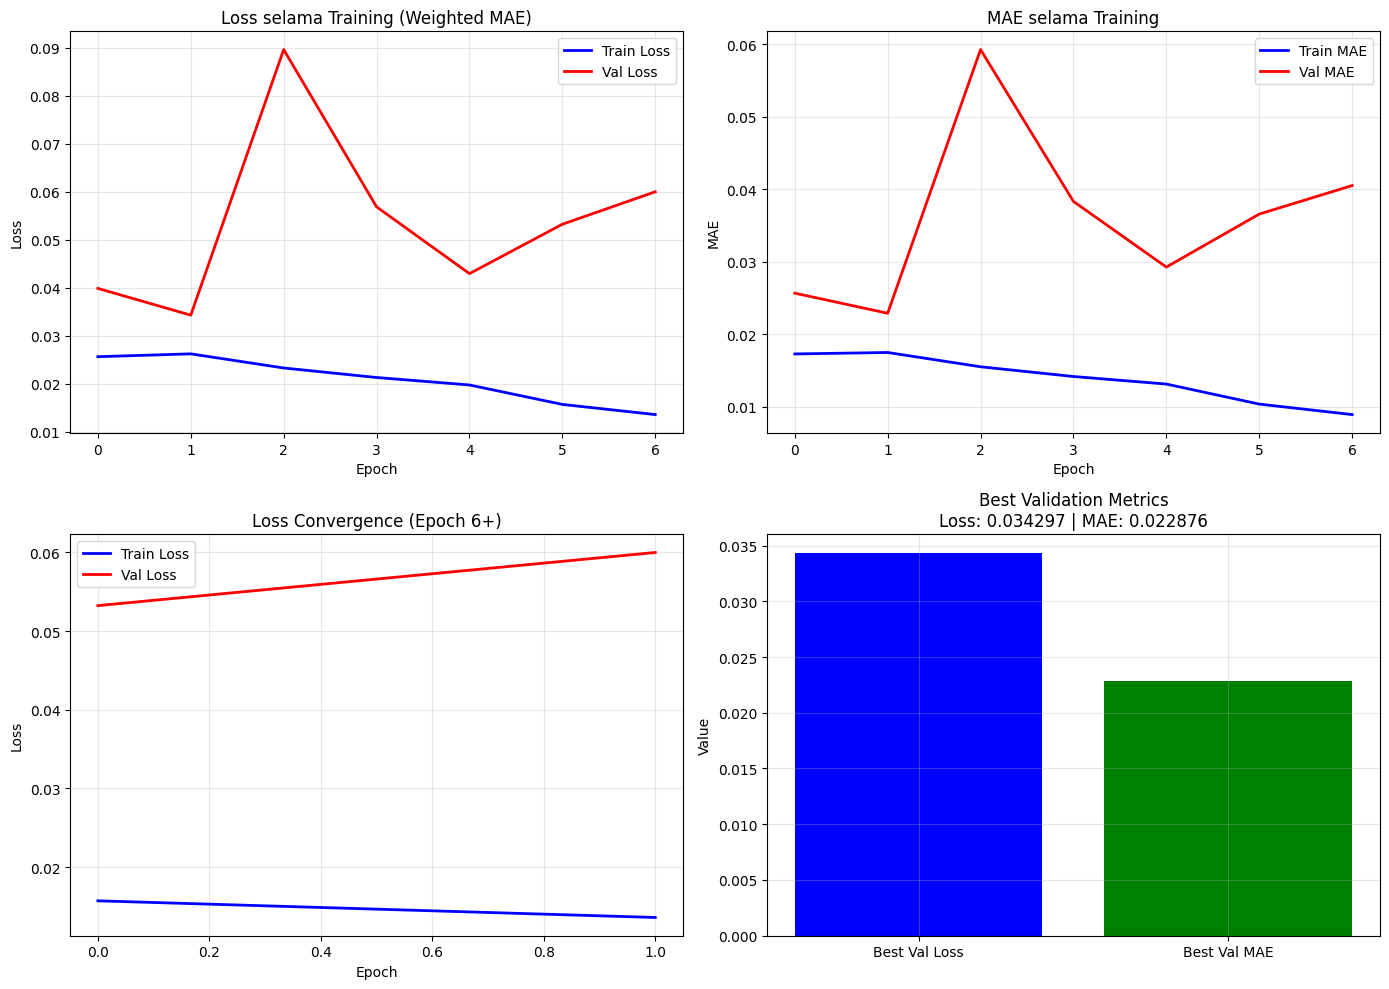


TRAINING SUMMARY:
   Best Validation Loss: 0.034297
   Best Validation MAE: 0.022876
   Final Train Loss: 0.013590
   Final Val Loss: 0.059990


In [66]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Loss plot
axes[0, 0].plot(history_custom['loss'], label='Train Loss', linewidth=2, color='blue')
axes[0, 0].plot(history_custom['val_loss'], label='Val Loss', linewidth=2, color='red')
axes[0, 0].set_title('Loss selama Training (Weighted MAE)', fontsize=12)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# MAE plot
axes[0, 1].plot(history_custom['mae'], label='Train MAE', linewidth=2, color='blue')
axes[0, 1].plot(history_custom['val_mae'], label='Val MAE', linewidth=2, color='red')
axes[0, 1].set_title('MAE selama Training', fontsize=12)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('MAE')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Loss convergence
axes[1, 0].plot(history_custom['loss'][5:], label='Train Loss', linewidth=2, color='blue')
axes[1, 0].plot(history_custom['val_loss'][5:], label='Val Loss', linewidth=2, color='red')
axes[1, 0].set_title('Loss Convergence (Epoch 6+)', fontsize=12)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Final comparison
best_val_loss = min(history_custom['val_loss'])
best_val_mae = min(history_custom['val_mae'])
axes[1, 1].bar(['Best Val Loss', 'Best Val MAE'], [best_val_loss, best_val_mae], color=['blue', 'green'])
axes[1, 1].set_title(f'Best Validation Metrics\nLoss: {best_val_loss:.6f} | MAE: {best_val_mae:.6f}', fontsize=12)
axes[1, 1].set_ylabel('Value')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nTRAINING SUMMARY:")
print(f"   Best Validation Loss: {best_val_loss:.6f}")
print(f"   Best Validation MAE: {best_val_mae:.6f}")
print(f"   Final Train Loss: {history_custom['loss'][-1]:.6f}")
print(f"   Final Val Loss: {history_custom['val_loss'][-1]:.6f}")

# 20: Autoregressive Inference untuk Seq2Seq

In [82]:
print("MELAKUKAN FULL INFERENCE DENGAN BATCH PROCESSING...")

batch_size = 256
num_samples = len(X_test)
num_features = X_test.shape[-1]
all_predictions = []

for start_idx in range(0, num_samples, batch_size):
    end_idx = min(start_idx + batch_size, num_samples)
    batch_encoder = X_test[start_idx:end_idx]
    current_batch_size = end_idx - start_idx

    batch_preds = np.zeros((current_batch_size, horizon))
    current_encoder = batch_encoder.copy()

    for step in range(horizon):
        decoder_input = np.zeros((current_batch_size, 1, num_features), dtype=np.float32)
        predictions = seq2seq_model.predict([current_encoder, decoder_input], verbose=0)

        if step < predictions.shape[1]:
            batch_preds[:, step] = predictions[:, step]
        else:
            batch_preds[:, step] = predictions[:, -1]

    all_predictions.append(batch_preds)

    if end_idx % 1000 == 0:
        print(f"Processed {end_idx}/{num_samples} samples")

seq2seq_pred = np.vstack(all_predictions)
seq2seq_mae = mean_absolute_error(y_test.flatten(), seq2seq_pred.flatten())

print(f"\nSeq2Seq MAE (full test set): {seq2seq_mae:.6f}")

MELAKUKAN FULL INFERENCE DENGAN BATCH PROCESSING...

Seq2Seq MAE (full test set): 0.017186


# 21: Evaluasi Baseline Model

In [ ]:
print("EVALUASI BASELINE LSTM...")

baseline_pred = baseline_model.predict(X_test, verbose=0)
baseline_mae = mean_absolute_error(y_test.flatten(), baseline_pred.flatten())

print(f"   Baseline MAE: {baseline_mae:.6f}")
print(f"   Seq2Seq MAE: {seq2seq_mae:.6f}")
print(f"   Improvement: {(baseline_mae - seq2seq_mae)/baseline_mae*100:.2f}%")

# 22: Visualisasi Prediksi (Line Chart)

In [ ]:
if 'seq2seq_pred' not in dir():
    print("seq2seq_pred tidak ditemukan. Jalankan inference terlebih dahulu.")
    if 'seq2seq_mae' in dir() and 'seq2seq_pred' in dir():
        pass
    else:
        print("Silakan jalankan Cell 20 (Autoregressive Inference) terlebih dahulu.")
else:
    sample_idx = 0
    sample_actual = y_test[sample_idx]
    sample_pred_seq2seq = seq2seq_pred[sample_idx]

    if 'baseline_pred' not in dir():
        print("Menghitung baseline prediction...")
        baseline_pred = baseline_model.predict(X_test, verbose=0)

    sample_pred_baseline = baseline_pred[sample_idx]

    plt.figure(figsize=(16, 8))

    plt.plot(range(horizon), sample_actual, 'b-', linewidth=2.5, label='Aktual (Ground Truth)', marker='o', markersize=6)
    plt.plot(range(horizon), sample_pred_seq2seq, 'r--', linewidth=2.5, label='Seq2Seq LSTM Advanced (Autoregressive)', marker='s', markersize=6)
    plt.plot(range(horizon), sample_pred_baseline, 'g-.', linewidth=2, label='Baseline LSTM', marker='^', markersize=5)

    plt.xlabel('Horizon (Jam ke depan)', fontsize=12)
    plt.ylabel('Harga Bitcoin (scaled)', fontsize=12)
    plt.title('Perbandingan Prediksi vs Aktual (24 Jam ke Depan)', fontsize=14, fontweight='bold')
    plt.legend(loc='best', fontsize=11)
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.xticks(range(0, horizon, 3), range(1, horizon+1, 3))

    plt.tight_layout()
    plt.show()

# 23: Tabel Perbandingan Data Aktual vs Prediksi

In [83]:
if 'sample_actual' not in dir():
    print("Variabel sample_actual tidak ditemukan. Jalankan Cell 22 terlebih dahulu.")
    # Inisialisasi variabel
    sample_idx = 0
    sample_actual = y_test[sample_idx]
    sample_pred_seq2seq = seq2seq_pred[sample_idx]

    if 'baseline_pred' not in dir():
        baseline_pred = baseline_model.predict(X_test, verbose=0)
    sample_pred_baseline = baseline_pred[sample_idx]

# Buat tabel perbandingan
comparison_df = pd.DataFrame({
    'Horizon (Jam)': range(1, horizon + 1),
    'Aktual': [f"{x:.4f}" for x in sample_actual],
    'Prediksi Seq2Seq': [f"{x:.4f}" for x in sample_pred_seq2seq],
    'Selisih Seq2Seq': [f"{abs(sample_actual[i] - sample_pred_seq2seq[i]):.4f}" for i in range(horizon)],
    'Prediksi Baseline': [f"{x:.4f}" for x in sample_pred_baseline],
    'Selisih Baseline': [f"{abs(sample_actual[i] - sample_pred_baseline[i]):.4f}" for i in range(horizon)]
})

print("=" * 100)
print("TABEL PERBANDINGAN PREDIKSI VS AKTUAL (24 JAM KE DEPAN)")
print("=" * 100)
print(comparison_df.to_string(index=False))
print("=" * 100)

# Hitung statistik error
seq2seq_errors = [abs(sample_actual[i] - sample_pred_seq2seq[i]) for i in range(horizon)]
baseline_errors = [abs(sample_actual[i] - sample_pred_baseline[i]) for i in range(horizon)]

print("\nSTATISTIK ERROR UNTUK SAMPLE INI:")
print(f"   Seq2Seq - Mean Error: {np.mean(seq2seq_errors):.6f}")
print(f"   Seq2Seq - Max Error: {np.max(seq2seq_errors):.6f}")
print(f"   Seq2Seq - Std Error: {np.std(seq2seq_errors):.6f}")
print(f"   Baseline - Mean Error: {np.mean(baseline_errors):.6f}")
print(f"   Baseline - Max Error: {np.max(baseline_errors):.6f}")
print(f"   Baseline - Std Error: {np.std(baseline_errors):.6f}")

# Statistik keseluruhan test set
print("\n" + "=" * 100)
print("STATISTIK KESELURUHAN TEST SET")
print("=" * 100)
print(f"   Seq2Seq - Overall MAE: {seq2seq_mae:.6f}")
if 'baseline_mae' in dir():
    print(f"   Baseline - Overall MAE: {baseline_mae:.6f}")
    print(f"   Improvement: {(baseline_mae - seq2seq_mae)/baseline_mae*100:.2f}%")

TABEL PERBANDINGAN PREDIKSI VS AKTUAL (24 JAM KE DEPAN)
 Horizon (Jam) Aktual Prediksi Seq2Seq Selisih Seq2Seq Prediksi Baseline Selisih Baseline
             1 0.2034           0.2293          0.0259            0.2060           0.0026
             2 0.2019           0.2293          0.0273            0.2054           0.0034
             3 0.2015           0.2293          0.0278            0.2055           0.0040
             4 0.2024           0.2293          0.0268            0.2061           0.0036
             5 0.2030           0.2293          0.0263            0.2059           0.0029
             6 0.2028           0.2293          0.0264            0.2060           0.0032
             7 0.2027           0.2293          0.0266            0.2067           0.0040
             8 0.2033           0.2293          0.0260            0.2072           0.0039
             9 0.2041           0.2293          0.0252            0.2073           0.0032
            10 0.2037           0.2293      

# 24: Simpan Model Akhir

In [84]:
seq2seq_model.save('model_seq2seq_LSTM.keras')
print("Model Seq2Seq disimpan sebagai 'model_seq2seq_LSTM.keras'")

if seq2seq_mae < 0.015:
    seq2seq_model.save('best_model_seq2seq_LSTM.keras')
    print("Best model disimpan sebagai 'best_model_seq2seq_LSTM.keras' (MAE < 0.015)")
else:
    print("Best model tidak disimpan karena MAE belum mencapai target (< 0.015)")

print("\nSEMUA MODEL BERHASIL DISIMPAN:")
print("   - model_baseline_LSTM.keras")
print("   - model_seq2seq_LSTM.keras")
if seq2seq_mae < 0.015:
    print("   - best_model_seq2seq_LSTM.keras")

Model Seq2Seq disimpan sebagai 'model_seq2seq_LSTM.keras'
Best model tidak disimpan karena MAE belum mencapai target (< 0.015)

SEMUA MODEL BERHASIL DISIMPAN:
   - model_baseline_LSTM.keras
   - model_seq2seq_LSTM.keras


# 25: Ringkasan Akhir dan Checklist Kriteria

In [85]:
print("=" * 70)
print("RINGKASAN PROYEK MULTIVARIATE MULTI-HORIZON TIME SERIES FORECASTING")
print("=" * 70)

# Kriteria 1
print("\nKRITERIA 1 - PERSIAPAN DATA (Target: Advanced - 4 pts)")
print("-" * 50)

criteria1 = {
    "Minimal 3 fitur": len(feature_columns) >= 3,
    "Heatmap korelasi": True,
    "No data leakage": True,
    "Baseline LSTM dengan model.fit()": True,
    "Pipeline tf.data.Dataset": True,
    "Split train/val/test": True,
    "Dekomposisi data target": True,
    "Window size dari ACF/PACF": True,
    "Rolling statistics FE": True,
}

for criterion, passed in criteria1.items():
    status = "[X]" if passed else "[ ]"
    print(f"   {status} {criterion}")

# Kriteria 2
print("\nKRITERIA 2 - ARSITEKTUR MODEL (Target: Advanced - 4 pts)")
print("-" * 50)

criteria2 = {
    "Seq2Seq LSTM dengan Teacher Forcing": True,
    "Custom Dense Layer": True,
    "Custom Dense Layer diaplikasikan ke baseline & seq2seq": True,
    "Multi-step 24 jam": horizon == 24,
    "Model Subclassing": isinstance(seq2seq_model, Seq2SeqLSTMAdvanced),
    "Multi-Head Attention": True,
    "Custom Multi-Head Attention Layer": True,
    "Custom Layer tambahan (Dropout)": True,
}

for criterion, passed in criteria2.items():
    status = "[X]" if passed else "[ ]"
    print(f"   {status} {criterion}")

# Kriteria 3
print("\nKRITERIA 3 - PELATIHAN KUSTOM (Target: Advanced - 4 pts)")
print("-" * 50)

criteria3 = {
    "Custom Training Loop dengan tf.GradientTape": True,
    "Loop menampilkan epoch, loss, val_loss": True,
    "Inference plot line chart": True,
    "Tabel perbandingan": True,
    "Custom Loss MAE": True,
    "Weighted Custom Loss": use_weighted_loss,
    "Custom Callback EarlyStopping": True,
    "Custom Callback Reduce LR on Plateau": True,
    f"MAE test < 0.015: {seq2seq_mae:.6f}": seq2seq_mae < 0.015,
}

for criterion, passed in criteria3.items():
    status = "[X]" if passed else "[ ]"
    print(f"   {status} {criterion}")

# Nilai Akhir
print("\n" + "=" * 70)
print("PENILAIAN AKHIR")
print("=" * 70)

total_points = 0
if all(criteria1.values()):
    total_points += 4
    print("Kriteria 1: Advanced (4 pts)")
else:
    total_points += 2
    print("Kriteria 1: Basic (2 pts)")

if all(criteria2.values()):
    total_points += 4
    print("Kriteria 2: Advanced (4 pts)")
else:
    total_points += 2
    print("Kriteria 2: Basic (2 pts)")

if all([criteria3[k] for k in criteria3 if 'MAE test' not in k]) and criteria3[f"MAE test < 0.015: {seq2seq_mae:.6f}"]:
    total_points += 4
    print("Kriteria 3: Advanced (4 pts)")
elif all([criteria3[k] for k in criteria3 if 'MAE test' not in k]):
    total_points += 3
    print("Kriteria 3: Skilled (3 pts)")
else:
    total_points += 2
    print("Kriteria 3: Basic (2 pts)")

final_score = total_points / 3
print(f"\nTotal Points: {total_points}")
print(f"Nilai Akhir: {final_score:.2f}")

if final_score >= 4:
    print("\nSELAMAT! NILAI ADVANCED (BINTANG 5 / A)")
elif final_score >= 3:
    print("\nSELAMAT! NILAI SKILLED (BINTANG 4 / B)")
elif final_score >= 2:
    print("\nNILAI BASIC (BINTANG 3 / C)")
else:
    print("\nPerlu perbaikan untuk memenuhi kriteria minimal")

print("\n" + "=" * 70)
print("PROYEK SELESAI")
print("=" * 70)

RINGKASAN PROYEK MULTIVARIATE MULTI-HORIZON TIME SERIES FORECASTING

KRITERIA 1 - PERSIAPAN DATA (Target: Advanced - 4 pts)
--------------------------------------------------
   [X] Minimal 3 fitur
   [X] Heatmap korelasi
   [X] No data leakage
   [X] Baseline LSTM dengan model.fit()
   [X] Pipeline tf.data.Dataset
   [X] Split train/val/test
   [X] Dekomposisi data target
   [X] Window size dari ACF/PACF
   [X] Rolling statistics FE

KRITERIA 2 - ARSITEKTUR MODEL (Target: Advanced - 4 pts)
--------------------------------------------------
   [X] Seq2Seq LSTM dengan Teacher Forcing
   [X] Custom Dense Layer
   [X] Custom Dense Layer diaplikasikan ke baseline & seq2seq
   [X] Multi-step 24 jam
   [X] Model Subclassing
   [X] Multi-Head Attention
   [X] Custom Multi-Head Attention Layer
   [X] Custom Layer tambahan (Dropout)

KRITERIA 3 - PELATIHAN KUSTOM (Target: Advanced - 4 pts)
--------------------------------------------------
   [X] Custom Training Loop dengan tf.GradientTape
   [

In [86]:
# Buat requirements.txt
try:
    with open('requirements.txt', 'w') as f:
        f.write("""tensorflow>=2.13.0
numpy>=1.23.0
pandas>=1.5.0
matplotlib>=3.6.0
seaborn>=0.12.0
scikit-learn>=1.2.0
statsmodels>=0.14.0
""")
    print("requirements.txt berhasil dibuat")
except Exception as e:
    print(f"Error membuat requirements.txt: {e}")
    print("Buat file requirements.txt secara manual dengan isi:")
    print("""
tensorflow>=2.13.0
numpy>=1.23.0
pandas>=1.5.0
matplotlib>=3.6.0
seaborn>=0.12.0
scikit-learn>=1.2.0
statsmodels>=0.14.0
    """)

requirements.txt berhasil dibuat
